# Treloar (1974): Michaelis-Menten Enzyme Kinetic Model

Treloar (1974) considered the reaction rate in the presence of an enzyme treated and untreated with puromycin (a protein synthesis inhibitor). Here the concentration of the enzyme is in parts per million and the rate of the reaction is measured in counts per minute squared. The data used for this analysis can be obtained in R from `datasets::Puromycin`.

Using this data, we will explore how puromycin modified the reaction by fitting a Michaelis-Menten Model, which is a model for enzyme-catalysed reactions for the transformation of a substrate into a single product. The equation is
$$ V_i = \frac{\bar{V} \times C_i}{K_m + C_i} $$
where $V_i$ is the velocity of the reaction, $C_i$ is the substrate concentration, $\bar{V}$ is the limiting rate (or maximum velocity of the reaction), and $K_m$ is the Michaelis constant which the concentration of substrate at which the reaction rate is half of the total velocity.

## Setup

In [10]:
import numpy as np
import scipy as sp
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import delicatessen as deli
from delicatessen import MEstimator

print("Versions")
print("NumPy:       ", np.__version__)
print("SciPy:       ", sp.__version__)
print("Pandas:      ", pd.__version__)
print("Matplotlib:  ", mpl.__version__)
print("Delicatessen:", deli.__version__)

Versions
NumPy:        2.3.5
SciPy:        1.16.3
Pandas:       2.3.3
Matplotlib:   3.10.8
Delicatessen: 4.2


In [23]:
d = pd.read_csv("data/puromycin.csv")

As with most data analyses should, we begin with a visualization of the corresponding data points. Here, we will plot the rate by the concentration stratified by puromycin treatment. The following code applies this process.

In [24]:
conc = np.asarray(d['conc'])
rate = np.asarray(d['rate'])
puromycin = np.where(d['state'] == 'treated', 1, 0)

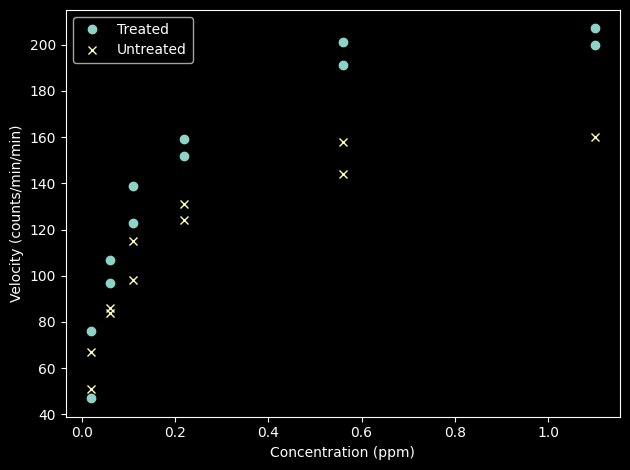

In [27]:
plt.plot(conc[puromycin == 1], rate[puromycin == 1], 'o', label='Treated')
plt.plot(conc[puromycin == 0], rate[puromycin == 0], 'x', label='Untreated')
plt.xlabel("Concentration (ppm)")
plt.ylabel("Velocity (counts/min/min)")
plt.legend()
plt.tight_layout()

We can see some visual differences, but we can do better and accompany this plot with some numeric estimates. We will do that by using the Michaelis-Menten model described previously.

## Overall Michaelis-Menten Model

To begin, we will fit an overall model to the data points. The following is the estimating functions for the Michaelis-Menten model, which is based on the score function of the corresponding model
$$ \psi(O_i; \theta) =
\begin{bmatrix}
  (V_i - \hat{V}_i) \times \left( \frac{C_i}{K_m + C_i} \right) \\
  (V_i - \hat{V}_i) \times \left( \frac{-\bar{V_m} C_i}{(K_m + C_i)^2} \right) \\
\end{bmatrix} $$
where $\hat{V_i}$ is the predicted value of the velocity from the model, the first function is for the max velocity ($\bar{V}$) and the second function is for $K_m$. The following is code to implement this model.

Note that the Michaelis-Menten model is not a very stable non-linear model. To help the root-finding process, we can select good starting values. For $\bar{V}$, we use the maximum rate observed in the data. For $K_m$, we can look at the previous plot. We see that halfway to the maximum velocity (i.e., 100) occurs around 0.1 for the concentration. Thus we use this as the starting value.

Finally, note that the data consists of only 23 observations. This is relatively few, thus the empirical sandwich variance estimator may not be a reliable estimator of the variance due to so few observations. To address this issue, we apply a finite-sample correction.

In [28]:
def psi_mmekm(theta):
    # Extracting parameters
    v_max, k_m = theta[0], theta[1]

    # Predicted velocity and residual calculations
    v_hat = v_max * conc / (k_m + conc)
    residual = rate - v_hat

    # Estimating functions for the parameters
    ef_vmax = (conc / (k_m + conc)) * residual
    ef_km = (-v_max * conc / (k_m + conc)**2) * residual

    # Returning stacked estimating functions
    return np.vstack([ef_vmax, ef_km])

In [29]:
estr = MEstimator(psi_mmekm, init=[np.max(rate), 0.1], finite_correction='hc1')
estr.estimate()

In [30]:
estr.print_results()

              Estimation Method: M-estimator
--------------------------------------------------------------
No. Observations:          23 | No. Parameters:              2
Solving algorithm:         lm | Max Iterations:           5000
Solving tolerance:      1e-09 | Allow P-Inverse:             1
Derivative Method:     approx | Deriv Approx:            1e-09
Small N Correction:       hc1 | Distribution:           t-stat
   Theta   StdErr  Z-score      LCL      UCL  P-value  S-value 
--------------------------------------------------------------
  190.81    11.42    16.71   167.07   214.55     0.00    42.79 
    0.06     0.01     5.03     0.04     0.09     0.00    14.13 


The previous analysis ignores the puromycin treatment, which we saw in the plot looks like it has an impact of the kinetics of the interaction. Therefore, we repeat the analysis but fit the models stratified by puromycin treatment

## Stratified Models

With estimating equations, we can easily estimate stratified models by simply limiting the contributions to the estimating functions to those within the strata of interest. We use the previous code and this method to estimate the stratified models

In [31]:
def psi_strata(theta):
    # Subset model parameters
    theta_0 = theta[:2]
    theta_1 = theta[2:]

    # Model among those treated with puromycin
    ef_puro = psi_mmekm(theta_0) * (puromycin == 1)

    # Model among those untreated with puromycin
    ef_nopur = psi_mmekm(theta_1) * (puromycin == 0)

    # Stacking estimating functions
    return np.vstack([ef_puro, ef_nopur])

In [33]:
estr = MEstimator(psi_strata, init=[np.max(rate), 0.1, np.max(rate), 0.1],
                  finite_correction='hc1')
estr.estimate()

In [34]:
estr.print_results()

              Estimation Method: M-estimator
--------------------------------------------------------------
No. Observations:          23 | No. Parameters:              4
Solving algorithm:         lm | Max Iterations:           5000
Solving tolerance:      1e-09 | Allow P-Inverse:             1
Derivative Method:     approx | Deriv Approx:            1e-09
Small N Correction:       hc1 | Distribution:           t-stat
   Theta   StdErr  Z-score      LCL      UCL  P-value  S-value 
--------------------------------------------------------------
  212.68     5.78    36.80   200.59   224.78     0.00    61.12 
    0.06     0.01     6.80     0.04     0.08     0.00    19.14 
  160.28     6.66    24.07   146.34   174.22     0.00    49.73 
    0.05     0.01     4.77     0.03     0.07     0.00    12.89 


These results suggest that there is a difference between the maximum velocity. However, there is random variability that is not directly incorporated. To formalize this comparison, we can stack in an additional estimating function for the difference between the maximum velocity between the strata. As the empirical sandwich variance estimator automates the delta method, we can easily obtain statistical inference for the differences between the maximum velocity. The following code applies this process.

In [35]:
def psi_test_diff(theta):
    # Subset model parameters
    model_params = theta[:4]
    diff = theta[4]

    # Stratified models
    ef_models = psi_strata(theta=model_params)

    # Estimating function for the difference
    v_max_puromycin = model_params[0]
    v_max_nopurom = model_params[2]
    ef_diff = (v_max_puromycin - v_max_nopurom) - diff * np.ones(rate.shape[0])

    # Stacking estimating functions
    return np.vstack([ef_models, ef_diff])

In [37]:
estr = MEstimator(psi_test_diff, init=[np.max(rate), 0.1, np.max(rate), 0.1, 0.],
                  finite_correction='hc1')
estr.estimate()

In [39]:
estr.print_results(subset=[-1])

              Estimation Method: M-estimator
--------------------------------------------------------------
No. Observations:          23 | No. Parameters:              5
Solving algorithm:         lm | Max Iterations:           5000
Solving tolerance:      1e-09 | Allow P-Inverse:             1
Derivative Method:     approx | Deriv Approx:            1e-09
Small N Correction:       hc1 | Distribution:           t-stat
   Theta   StdErr  Z-score      LCL      UCL  P-value  S-value 
--------------------------------------------------------------
   52.40     9.06     5.78    33.37    71.44     0.00    15.80 


Here, we see the estimated difference between the maximum velocities. As evident by the 95% confidence intervals (33.4, 71.4), this difference is quite substantial. Thus, we may reasonably conclude that puromycin does indeed modify the reaction rate.

The advantage of estimating equations (and `delicatessen`) in this context is that we are able to easily estimate stratified models, compare different parameters between the stratified models, and obtain valid statistical inference for the parameter comparisons. This is not the case when fitting stratified models generally.

## References

Michaelis L, & Menten ML. (1913). Die kinetik der invertinwirkung. *Biochem Z*, 49(333-369), 352.

Srinivasan B. (2022). A guide to the Michaelis–Menten equation: steady state and beyond. *The FEBS journal*, 289(20), 6086-6098.

Treloar MA. (1974). *Effects of Puromycin on Galactosyltansferase of Golgi Membranes*. Doctoral dissertation, University of Toronto